<a href="https://colab.research.google.com/github/myDream616828/CF_Mai23280018_Minh23280029/blob/main/%5BCF%5D_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-> Tải thành công và chia nhỏ thành 70 mã cổ phiếu.

--- PHÂN TÍCH CHI TIẾT THEO TỪNG MÃ ---

* TOP 5 MÃ CÓ ĐỘ BIẾN ĐỘNG CAO NHẤT (Rủi ro cao):
      Annual_Return  Annual_Volatility  Kurtosis  ADF_P_Value
TSLA         0.3828             0.5702    4.4444          0.0
AMD          0.3713             0.5625   10.5049          0.0
FCX          0.0042             0.5261    6.2045          0.0
NVDA         0.6925             0.4706    7.3986          0.0
NFLX         0.3073             0.4343   28.7482          0.0

* TOP 5 MÃ CÓ ĐỘ BIẾN ĐỘNG THẤP NHẤT (Rủi ro thấp):
       Annual_Return  Annual_Volatility  Kurtosis  ADF_P_Value
KO            0.0431             0.1770   10.2760          0.0
JNJ           0.0618             0.1806    9.3886          0.0
PG            0.0568             0.1817   10.9543          0.0
PEP           0.0467             0.1866   19.1920          0.0
BRK-B         0.1320             0.1896   10.9296          0.0


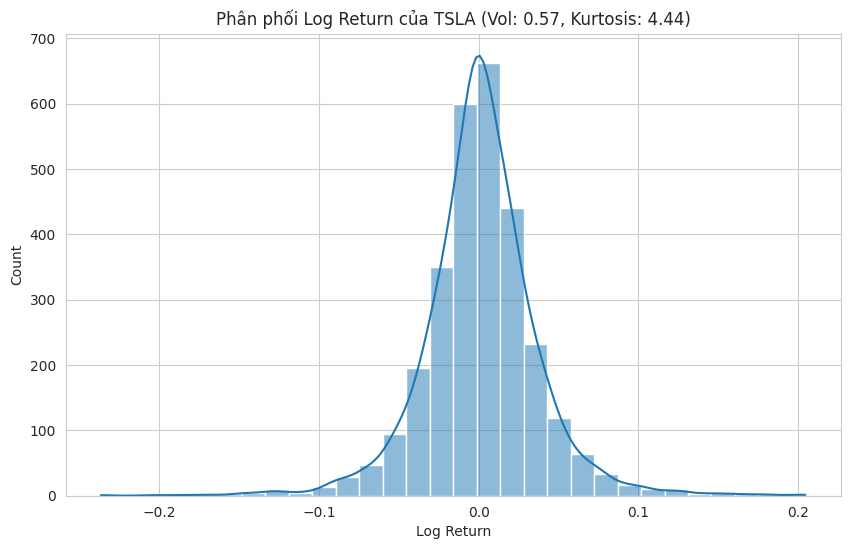


* TOP 5 MÃ CÓ SHARPE RATIO TIỀM NĂNG CAO NHẤT (Hiệu suất/Rủi ro):
      Annual_Return  Annual_Volatility  Sharpe_Potential
NVDA         0.6925             0.4706            1.4713
AVGO         0.4230             0.3814            1.1091
MSFT         0.2528             0.2644            0.9562
LLY          0.2595             0.2824            0.9188
COST         0.1928             0.2124            0.9075

--- TÍNH TOÁN PHÂN PHỐI LỢI NHUẬN VÀ TÍNH DỪNG (Tổng thể) ---

* Thống kê Skewness và Kurtosis:
      Skewness  Kurtosis
mean     -0.42     13.98
std       0.58      9.70


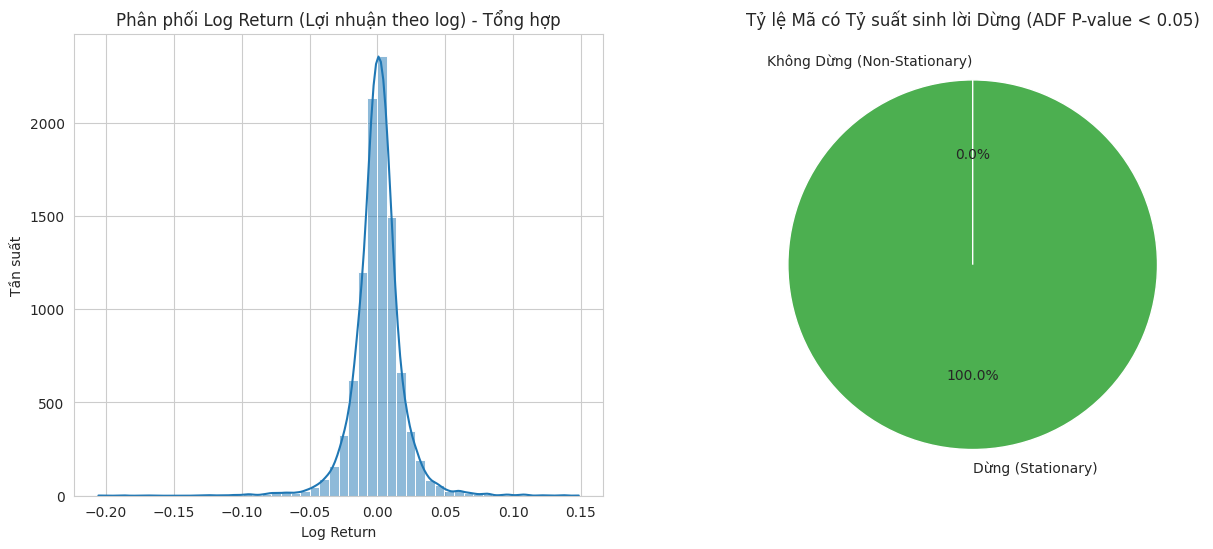


--- PHÂN TÍCH THỐNG KÊ THEO NGÀNH ---
                           Annual_Return  Annual_Volatility  ADF_P_Value
Sector                                                                  
Bất động sản                      0.0682             0.2706          0.0
Công nghiệp                       0.0912             0.2861          0.0
Công nghệ                         0.3261             0.3768          0.0
Dịch vụ Truyền thông              0.1666             0.3139          0.0
Năng lượng                        0.0232             0.3507          0.0
Tiêu dùng Không thiết yếu         0.1614             0.3137          0.0
Tiêu dùng Thiết yếu               0.0858             0.1961          0.0
Tiện ích                          0.0732             0.2177          0.0
Tài chính                         0.1457             0.2645          0.0
Vật liệu                          0.0897             0.3064          0.0
Y tế                              0.1099             0.2452          0.0


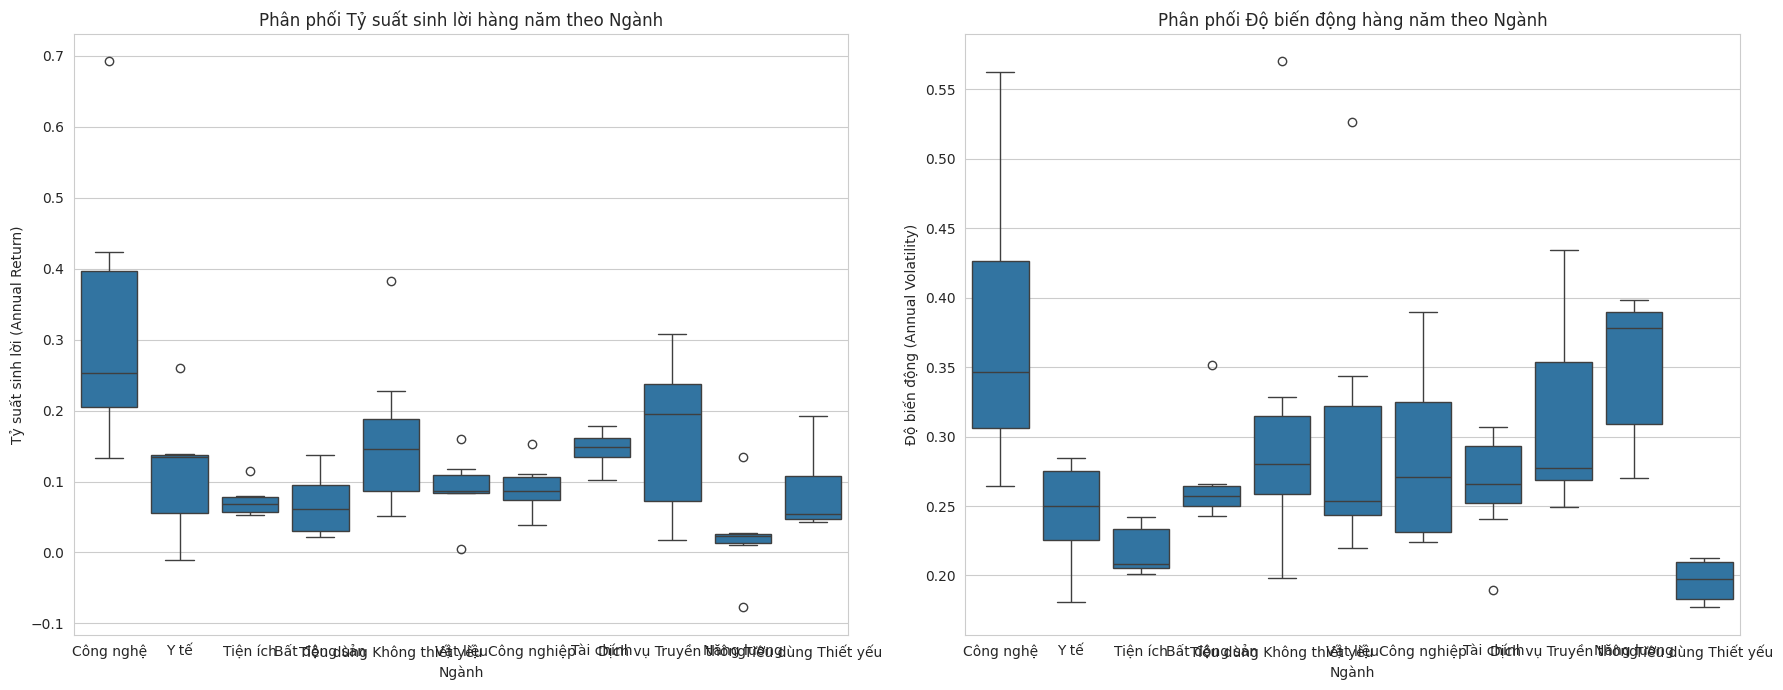

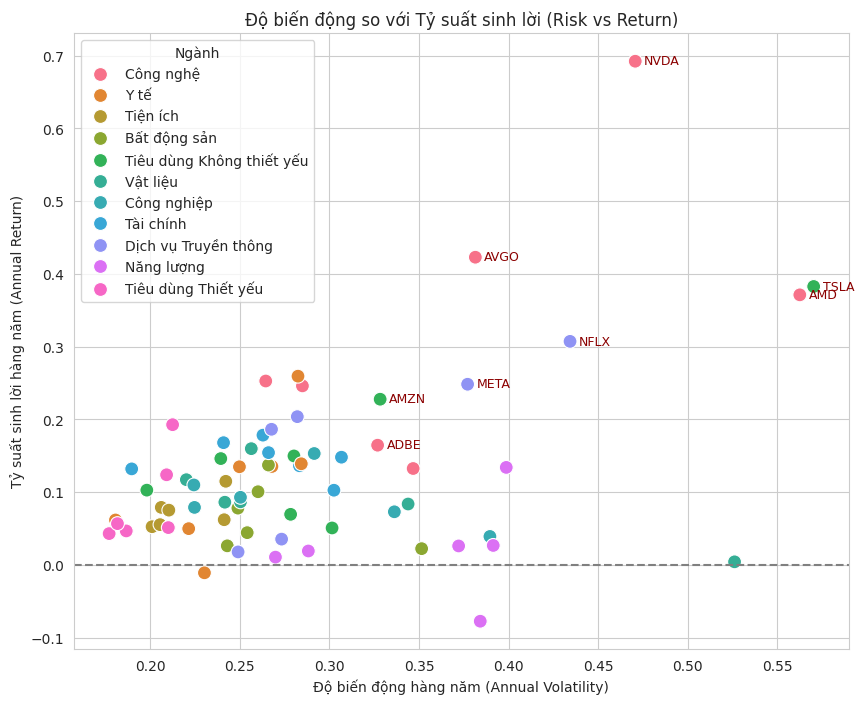


--- EDA HOÀN TẤT ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Thiết lập hiển thị cho biểu đồ
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10
DATA_FILE = "stock_data_70.csv"
TICKER_COL = 'Ticker'
CLOSE_COL = 'Close'
DATE_COL = 'Date'
# Tham số Ichimoku không cần thiết cho EDA này, nhưng giữ lại để chuẩn hóa
# --- PHÂN CÔNG NGÀNH (Sử dụng tickers_list để tạo mapping đầy đủ) ---
tickers_list = [
    # Công nghệ
    'AAPL', 'MSFT', 'NVDA', 'AVGO', 'ADBE', 'CRM', 'AMD',
    # Y tế
    'JNJ', 'LLY', 'UNH', 'MRK', 'PFE', 'TMO', 'ABBV',
    # Tài chính
    'JPM', 'BRK-B', 'V', 'MA', 'BAC', 'GS', 'MS',
    # Tiêu dùng Không thiết yếu
    'AMZN', 'TSLA', 'HD', 'MCD', 'NKE', 'SBUX', 'LOW',
    # Tiêu dùng Thiết yếu
    'PG', 'COST', 'KO', 'PEP', 'WMT', 'MDLZ',
    # Công nghiệp
    'CAT', 'GE', 'HON', 'UNP', 'BA', 'LMT',
    # Dịch vụ Truyền thông
    'GOOGL', 'META', 'NFLX', 'DIS', 'CMCSA', 'TMUS',
    # Năng lượng
    'XOM', 'CVX', 'COP', 'SLB', 'EOG', 'MPC',
    # Vật liệu
    'LIN', 'SHW', 'FCX', 'NUE', 'ECL', 'APD',
    # Bất động sản
    'AMT', 'PLD', 'EQIX', 'CCI', 'SPG', 'O',
    # Tiện ích
    'NEE', 'SO', 'DUK', 'SRE', 'AEP', 'ED'
]

SECTOR_MAPPING = {}
# Công nghệ
for ticker in ['AAPL', 'MSFT', 'NVDA', 'AVGO', 'ADBE', 'CRM', 'AMD']:
    SECTOR_MAPPING[ticker] = 'Công nghệ'
# Y tế
for ticker in ['JNJ', 'LLY', 'UNH', 'MRK', 'PFE', 'TMO', 'ABBV']:
    SECTOR_MAPPING[ticker] = 'Y tế'
# Tài chính
for ticker in ['JPM', 'BRK-B', 'V', 'MA', 'BAC', 'GS', 'MS']:
    SECTOR_MAPPING[ticker] = 'Tài chính'
# Tiêu dùng Không thiết yếu
for ticker in ['AMZN', 'TSLA', 'HD', 'MCD', 'NKE', 'SBUX', 'LOW']:
    SECTOR_MAPPING[ticker] = 'Tiêu dùng Không thiết yếu'
# Tiêu dùng Thiết yếu
for ticker in ['PG', 'COST', 'KO', 'PEP', 'WMT', 'MDLZ']:
    SECTOR_MAPPING[ticker] = 'Tiêu dùng Thiết yếu'
# Công nghiệp
for ticker in ['CAT', 'GE', 'HON', 'UNP', 'BA', 'LMT']:
    SECTOR_MAPPING[ticker] = 'Công nghiệp'
# Dịch vụ Truyền thông
for ticker in ['GOOGL', 'META', 'NFLX', 'DIS', 'CMCSA', 'TMUS']:
    SECTOR_MAPPING[ticker] = 'Dịch vụ Truyền thông'
# Năng lượng
for ticker in ['XOM', 'CVX', 'COP', 'SLB', 'EOG', 'MPC']:
    SECTOR_MAPPING[ticker] = 'Năng lượng'
# Vật liệu
for ticker in ['LIN', 'SHW', 'FCX', 'NUE', 'ECL', 'APD']:
    SECTOR_MAPPING[ticker] = 'Vật liệu'
# Bất động sản
for ticker in ['AMT', 'PLD', 'EQIX', 'CCI', 'SPG', 'O']:
    SECTOR_MAPPING[ticker] = 'Bất động sản'
# Tiện ích
for ticker in ['NEE', 'SO', 'DUK', 'SRE', 'AEP', 'ED']:
    SECTOR_MAPPING[ticker] = 'Tiện ích'

# Thiết lập ngành mặc định (sẽ không dùng nếu tất cả đã được map)
DEFAULT_SECTOR = 'Unknown'

# --- 1. HÀM TẢI DỮ LIỆU VÀ CHIA NHỎ DF ---
def load_and_split_data(data_file):
    all_tickers = {}
    try:
        df_full = pd.read_csv(
            data_file,
            parse_dates=[DATE_COL],
            thousands=',',
        )
        df_full.rename(columns={CLOSE_COL: 'Close'}, inplace=True)

        for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
            df_full[col] = pd.to_numeric(df_full[col], errors='coerce')
        df_full.dropna(subset=['Close', 'Volume'], inplace=True)

        tickers_list_data = df_full[TICKER_COL].unique()

        for ticker in tickers_list_data:
            df_ticker = df_full[df_full[TICKER_COL] == ticker].set_index(DATE_COL).sort_index()
            df_ticker = df_ticker.drop(columns=[TICKER_COL, 'Adj Close'], errors='ignore')
            all_tickers[ticker] = df_ticker

        print(f"-> Tải thành công và chia nhỏ thành {len(tickers_list_data)} mã cổ phiếu.")
        return all_tickers

    except FileNotFoundError:
        print(f"*** LỖI: Không tìm thấy file {data_file}.")
        return {}
    except Exception as e:
        print(f"*** LỖI khi tải hoặc xử lý dữ liệu: {e}")
        return {}

# --- 2. HÀM TÍNH TOÁN CÁC THÔNG SỐ EDA CƠ BẢN ---
def calculate_eda_metrics(all_tickers):
    metrics = {}

    for ticker, df in all_tickers.items():
        # Tính Tỷ suất sinh lời hàng ngày (log return)
        df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

        # Loại bỏ NaN do shift
        df = df.dropna(subset=['Log_Return'])

        # Tính toán các chỉ số
        if not df.empty:
            # Tính Tỷ suất sinh lời trung bình năm (Annualized Return)
            days = len(df)
            total_return_factor = df['Close'].iloc[-1] / df['Close'].iloc[0]
            annual_return = (total_return_factor ** (252 / days) - 1)

            # Độ biến động hàng năm (Annualized Volatility)
            annual_volatility = df['Log_Return'].std() * np.sqrt(252)

            # Skewness và Kurtosis
            skewness = df['Log_Return'].skew()
            kurtosis = df['Log_Return'].kurt()

            # Kiểm tra Tính dừng (Stationarity) bằng kiểm định ADF
            adf_result = adfuller(df['Log_Return'])
            is_stationary = adf_result[1] < 0.05 # P-value < 0.05

            metrics[ticker] = {
                'Annual_Return': annual_return,
                'Annual_Volatility': annual_volatility,
                'ADF_P_Value': adf_result[1],
                'Is_Stationary': is_stationary,
                'Skewness': skewness,
                'Kurtosis': kurtosis,
                'Total_Days': days,
                'df_return': df['Log_Return'] # Lưu lại series lợi nhuận cho việc vẽ biểu đồ
            }

    return pd.DataFrame.from_dict(metrics, orient='index')


# --- 3. HÀM PHÂN TÍCH VÀ TRỰC QUAN HÓA NHÓM NGÀNH ---
def analyze_and_plot_sectors(metrics_df, mapping):

    # Gán ngành cho từng mã
    metrics_df['Sector'] = metrics_df.index.map(lambda x: mapping.get(x, DEFAULT_SECTOR))

    print("\n--- PHÂN TÍCH THỐNG KÊ THEO NGÀNH ---")
    sector_stats = metrics_df.groupby('Sector')[['Annual_Return', 'Annual_Volatility', 'ADF_P_Value']].mean()
    print(sector_stats.round(4))

    # 3.1. Trực quan hóa Lợi nhuận & Biến động theo Ngành
    plt.figure(figsize=(18, 7))

    plt.subplot(1, 2, 1)
    sns.boxplot(x='Sector', y='Annual_Return', data=metrics_df)
    plt.title('Phân phối Tỷ suất sinh lời hàng năm theo Ngành')
    plt.ylabel('Tỷ suất sinh lời (Annual Return)')
    plt.xlabel('Ngành')

    plt.subplot(1, 2, 2)
    sns.boxplot(x='Sector', y='Annual_Volatility', data=metrics_df)
    plt.title('Phân phối Độ biến động hàng năm theo Ngành')
    plt.ylabel('Độ biến động (Annual Volatility)')
    plt.xlabel('Ngành')

    plt.tight_layout()
    plt.show()

    # 3.2. Trực quan hóa Biểu đồ phân tán (Risk vs Return)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='Annual_Volatility',
        y='Annual_Return',
        hue='Sector',
        data=metrics_df,
        s=100
    )
    # Thêm nhãn cho các mã có hiệu suất cao/rủi ro cao
    for i, row in metrics_df.iterrows():
        if row['Annual_Return'] > metrics_df['Annual_Return'].quantile(0.75) and row['Annual_Volatility'] > metrics_df['Annual_Volatility'].quantile(0.75):
            plt.text(row['Annual_Volatility'] + 0.005, row['Annual_Return'] - 0.005, i, fontsize=9, color='darkred')

    plt.axhline(0, color='gray', linestyle='--')
    plt.title('Độ biến động so với Tỷ suất sinh lời (Risk vs Return)')
    plt.xlabel('Độ biến động hàng năm (Annual Volatility)')
    plt.ylabel('Tỷ suất sinh lời hàng năm (Annual Return)')
    plt.legend(title='Ngành')
    plt.show()


# --- 4. HÀM PHÂN TÍCH PHÂN PHỐI VÀ TÍNH DỪNG ---

# 4.1. Phân tích phân phối và tính dừng tổng quát
def analyze_distribution_and_stationarity_general(metrics_df):

    print("\n--- TÍNH TOÁN PHÂN PHỐI LỢI NHUẬN VÀ TÍNH DỪNG (Tổng thể) ---")

    # 4.1.1. Thống kê Skewness và Kurtosis
    print("\n* Thống kê Skewness và Kurtosis:")
    dist_stats = metrics_df[['Skewness', 'Kurtosis']].describe().loc[['mean', 'std']]
    print(dist_stats.round(2))

    plt.figure(figsize=(15, 6))

    # 4.1.2. Biểu đồ Histogram của Log Return tổng hợp
    plt.subplot(1, 2, 1)

    # Tạo Log Return tổng hợp từ tất cả các mã (chỉ lấy 10000 mẫu để trực quan nhanh)
    all_log_returns = pd.concat(metrics_df['df_return'].tolist()).sample(min(10000, pd.concat(metrics_df['df_return'].tolist()).shape[0]))
    sns.histplot(all_log_returns, kde=True, bins=50)
    plt.title('Phân phối Log Return (Lợi nhuận theo log) - Tổng hợp')
    plt.xlabel('Log Return')
    plt.ylabel('Tần suất')

    # 4.1.3. Trực quan hóa Tính dừng tổng quát
    plt.subplot(1, 2, 2)
    stationary_counts = metrics_df['Is_Stationary'].value_counts()

    # Reindex to ensure both True and False are present, fill with 0 if not
    full_stationary_counts = stationary_counts.reindex([True, False], fill_value=0)

    # Prepare labels based on the order of full_stationary_counts
    labels_map = {True: 'Dừng (Stationary)', False: 'Không Dừng (Non-Stationary)'}
    labels_for_pie = [labels_map[idx] for idx in full_stationary_counts.index]

    plt.pie(
        full_stationary_counts,
        labels=labels_for_pie,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#4CAF50', '#FF9800']
    )
    plt.title('Tỷ lệ Mã có Tỷ suất sinh lời Dừng (ADF P-value < 0.05)')
    plt.show()

# 4.2. Phân tích Chi tiết từng mã (NEW)
def analyze_individual_stocks(metrics_df, all_tickers):
    print("\n--- PHÂN TÍCH CHI TIẾT THEO TỪNG MÃ ---")

    # Xếp hạng Top 5 mã có độ biến động cao nhất (Rủi ro cao nhất)
    top_volatility = metrics_df.sort_values(by='Annual_Volatility', ascending=False).head(5)
    print("\n* TOP 5 MÃ CÓ ĐỘ BIẾN ĐỘNG CAO NHẤT (Rủi ro cao):")
    print(top_volatility[['Annual_Return', 'Annual_Volatility', 'Kurtosis', 'ADF_P_Value']].round(4))

    # Xếp hạng Top 5 mã có độ biến động thấp nhất (Rủi ro thấp nhất)
    bottom_volatility = metrics_df.sort_values(by='Annual_Volatility', ascending=True).head(5)
    print("\n* TOP 5 MÃ CÓ ĐỘ BIẾN ĐỘNG THẤP NHẤT (Rủi ro thấp):")
    print(bottom_volatility[['Annual_Return', 'Annual_Volatility', 'Kurtosis', 'ADF_P_Value']].round(4))

    # Lấy mã có độ biến động cao nhất để vẽ biểu đồ phân phối chi tiết
    highest_vol_ticker = top_volatility.index[0]
    df_highest_vol = all_tickers[highest_vol_ticker]

    # Vẽ biểu đồ phân phối lợi nhuận (Log Return) của mã rủi ro cao nhất
    plt.figure(figsize=(10, 6))
    sns.histplot(df_highest_vol['Log_Return'].dropna(), kde=True, bins=30)

    # Thêm các chỉ số thống kê vào biểu đồ
    vol_val = top_volatility.loc[highest_vol_ticker, 'Annual_Volatility']
    kurt_val = top_volatility.loc[highest_vol_ticker, 'Kurtosis']
    plt.title(f'Phân phối Log Return của {highest_vol_ticker} (Vol: {vol_val:.2f}, Kurtosis: {kurt_val:.2f})')
    plt.xlabel('Log Return')
    plt.show()

    # Xếp hạng Top 5 mã có Sharpe Ratio tiềm năng (Giả định tỷ lệ lợi nhuận/rủi ro)
    metrics_df['Sharpe_Potential'] = metrics_df['Annual_Return'] / metrics_df['Annual_Volatility']
    top_sharpe = metrics_df.sort_values(by='Sharpe_Potential', ascending=False).head(5)
    print("\n* TOP 5 MÃ CÓ SHARPE RATIO TIỀM NĂNG CAO NHẤT (Hiệu suất/Rủi ro):")
    print(top_sharpe[['Annual_Return', 'Annual_Volatility', 'Sharpe_Potential']].round(4))

    # Xóa cột tạm
    metrics_df.drop(columns=['Sharpe_Potential'], inplace=True)


# --- 5. CHẠY TOÀN BỘ QUÁ TRÌNH EDA ---

# 5.1. Tải và chuẩn bị dữ liệu
all_tickers = load_and_split_data(DATA_FILE)

if all_tickers:
    # 5.2. Tính toán các chỉ số EDA
    metrics_df = calculate_eda_metrics(all_tickers)

    # 5.3. Phân tích Chi tiết từng mã (MỚI)
    analyze_individual_stocks(metrics_df.copy(), all_tickers) # Sử dụng bản copy để tránh lỗi khi thêm cột tạm

    # 5.4. Phân tích Phân phối và Tính dừng tổng quát
    analyze_distribution_and_stationarity_general(metrics_df)

    # 5.5. Phân tích Ngành
    analyze_and_plot_sectors(metrics_df, SECTOR_MAPPING)

    print("\n--- EDA HOÀN TẤT ---")